In [1]:
import numpy as np
import sympy as sp
from sympy import sqrt, zeros, S,  Matrix, binomial
import matplotlib.pyplot as plt
from sympy.physics.quantum import TensorProduct
from sympy.physics.quantum.trace import Tr
from sympy import lambdify, simplify
from math import comb, isnan
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
import seaborn as sns
%matplotlib inline
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    # font.size was 20
    "font.size": 25
})

In [2]:
# Identity operators for ion and photon Hilbert spaces
id_ion = sp.eye(2)
id_photon = sp.eye(5)

# Basis vectors for the ion
ket_0_ion = sp.Matrix([1, 0])
ket_1_ion = sp.Matrix([0, 1])

bra_0_ion = ket_0_ion.T
bra_1_ion = ket_1_ion.T

# Basis vectors for the photon (Assume there is at most four photon at each optical mode)
ket_0_photon = sp.Matrix([1, 0, 0, 0, 0])
ket_1_photon = sp.Matrix([0, 1, 0, 0, 0])
ket_2_photon = sp.Matrix([0, 0, 1, 0, 0])
ket_3_photon = sp.Matrix([0, 0, 0, 1, 0])
ket_4_photon = sp.Matrix([0, 0, 0, 0, 1])

bra_0_photon = ket_0_photon.T
bra_1_photon = ket_1_photon.T
bra_2_photon = ket_2_photon.T
bra_3_photon = ket_3_photon.T
bra_4_photon = ket_4_photon.T

# Define Bell states for the ions
phi_plus = (1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_0_ion) + TensorProduct(ket_1_ion, ket_1_ion))
psi_plus = (1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_1_ion) + TensorProduct(ket_1_ion, ket_0_ion))
psi_minus = (1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_1_ion) - TensorProduct(ket_1_ion, ket_0_ion))
phi_minus = (1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_0_ion) - TensorProduct(ket_1_ion, ket_1_ion))

In [3]:
def normalize(dm):
    '''
    Return the normalized version of density matrix.
    '''
    return dm / Tr(dm)

def get_heralded_dm_spdc(dm):
    '''
    Return the "un-normalized" density matrix after the center swapping station for SPDC clicks. Assume photon-number-resolving detectors.
    
    The state is |QM1, Fiber1, QM2, Fiber2>

    We consider only one possible detection pattern. Other detection patterns are locally equivalent to this one up to local Z rotation.
    '''

    # Output mode written in the basis of input mode.
    o_10 = (1/sqrt(2)) * (TensorProduct(id_photon, ket_0_photon, id_photon, ket_1_photon) + TensorProduct(id_photon, ket_1_photon, id_photon, ket_0_photon))
    rho_10 = o_10.T @ dm @ o_10

    return rho_10


def get_heralded_dm_load_1(dm):
    '''
    Return the "un-normalized" density matrix after the loading to first ion-trap. Assume number-resolving detectors.
    
    The state is |QM1, QM2, ion1, photon1>
    '''

    # Output mode written in the basis of input mode.
    
    o_10 = (1/sqrt(2)) * (1 * TensorProduct(ket_1_photon, id_photon, id_ion, ket_0_photon) + 1 * TensorProduct(ket_0_photon, id_photon, id_ion, ket_1_photon))


    # The heralded QM state with different photon numbers.
    
    rho_10 = o_10.T @ dm @ o_10


    return rho_10

def get_heralded_dm_load_2(dm):
    '''
    Return the "un-normalized" density matrix after the loading to second ion-trap. Assume number-resolving detectors.
    
    The state is |QM2, ion1, ion2, photon2>
    '''

    # Output mode written in the basis of input mode.
    
    o_10 = (1/sqrt(2)) * (1 * TensorProduct(ket_1_photon, id_ion, id_ion, ket_0_photon) + 1 * TensorProduct(ket_0_photon, id_ion, id_ion, ket_1_photon))


    # The heralded QM state with different photon numbers.
    
    rho_10 = o_10.T @ dm @ o_10
    
    return rho_10 

def amplitude_damping_kraus_fiber(d):
    '''
    Generate the Kraus operators for the amplitude damping channel 

    Input:
    d: dimension of the bosonic state. (Maximum number of photons = d-1)
    '''
    
    kraus_ops = []
    for k in range(d):
        K = Matrix.zeros(d, d)
        for n in range(k, d):
            amp = sqrt(binomial(n, k)) * ((1 - p)**((n - k)/2)) * (p**(k/2))
            K[n - k, n] = amp
        kraus_ops.append(K)
    
    return kraus_ops

def amplitude_damping_kraus_qm(d):
    '''
    Generate the Kraus operators for the amplitude damping channel 

    Input:
    d: dimension of the bosonic state. (Maximum number of photons = d-1)
    '''
    
    kraus_ops = []
    for k in range(d):
        K = Matrix.zeros(d, d)
        for n in range(k, d):
            amp = sqrt(binomial(n, k)) * ((1 - p_m)**((n - k)/2)) * (p_m**(k/2))
            K[n - k, n] = amp
        kraus_ops.append(K)
    
    return kraus_ops

def amplitude_damping_kraus_ion_emission(d):
    '''
    Generate the Kraus operators for the amplitude damping channel 

    Input:
    d: dimension of the bosonic state. (Maximum number of photons = d-1)
    '''
    
    kraus_ops = []
    for k in range(d):
        K = Matrix.zeros(d, d)
        for n in range(k, d):
            amp = sqrt(binomial(n, k)) * ((1 - p_i)**((n - k)/2)) * (p_i**(k/2))
            K[n - k, n] = amp
        kraus_ops.append(K)
    
    return kraus_ops

def merge_ELs(p_vec, n_qpu):
    pI, pX, pY, pZ = p_vec
    num_links = n_qpu-1
    out_pI, out_pX, out_pY, out_pZ = pI, pX, pY, pZ

    for _ in range(num_links - 1):
        out_pI, out_pX, out_pY, out_pZ = (
            out_pI*pI + out_pX*pX + out_pY*pY + out_pZ*pZ,
            out_pI*pX + out_pX*pI + out_pY*pZ + out_pZ*pY,
            out_pI*pY + out_pY*pI + out_pX*pZ + out_pZ*pX,
            out_pI*pZ + out_pZ*pI + out_pX*pY + out_pY*pX
        )
    result = np.array([out_pI, out_pX, out_pY, out_pZ])
    return result/np.sum(result)


def apply_ED_protocol(dm):

    input_dm = TensorProduct(dm, dm)

    x_gate = Matrix([[0,1], [1,0]])

    # |a, b, a, b>
    CNOT_alice = TensorProduct(ket_0_ion @ bra_0_ion, id_ion, id_ion, id_ion) + TensorProduct(ket_1_ion @ bra_1_ion, id_ion, x_gate, id_ion)
    CNOT_bob = TensorProduct(id_ion, ket_0_ion @ bra_0_ion, id_ion, id_ion) + TensorProduct(id_ion, ket_1_ion @ bra_1_ion, id_ion, x_gate)

    dm_cnot = CNOT_bob @ (CNOT_alice @ input_dm @ CNOT_alice.T) @ CNOT_bob.T
    post_select_dm = TensorProduct(id_ion, id_ion, bra_1_ion, bra_1_ion) * dm_cnot * TensorProduct(id_ion, id_ion, ket_1_ion, ket_1_ion)
    prob = Tr(post_select_dm)
    return normalize(post_select_dm), prob

def get_p_vec(dm):
    dm_np = np.array(dm)
    pI = (phi_plus.T @ dm_np @ phi_plus)[0][0]
    pX = (psi_plus.T @ dm_np @ psi_plus)[0][0]
    pY = (psi_minus.T @ dm_np @ psi_minus)[0][0]
    pZ = (phi_minus.T @ dm_np @ phi_minus)[0][0]

    # Assume local rotation back to pI (change Pauli frame)
    return np.array([pX, pI, pZ, pY])

def get_SPDC_coeffs(lam):

    N0 = np.sqrt(1-lam**2)

    c0 = N0 * (lam ** 0)
    c1 = N0 * (lam ** 1)
    c2 = N0 * (lam ** 2)
    
    length = np.sqrt(c0**2 + c1**2 + c2**2)

    return c0/length, c1/length, c2/length

def get_p_vec(dm):
    dm_np = np.array(dm)
    pI = (phi_plus.T @ dm_np @ phi_plus)[0]
    pX = (psi_plus.T @ dm_np @ psi_plus)[0]
    pY = (psi_minus.T @ dm_np @ psi_minus)[0]
    pZ = (phi_minus.T @ dm_np @ phi_minus)[0]

    # Assume local rotation back to pI (change Pauli frame)
    return np.array([pX, pI, pZ, pY])

def fidelity(dm):
    return get_p_vec(dm)[0]

In [4]:
# Components for the SPDC state, up to two-photon emission.
p0 = sp.symbols('p_0')
p1 = sp.symbols('p_1')
p2 = sp.symbols('p_2')

# Brightness of the ion.
q = sp.symbols('q')

# The total loss for one-arm (remote)
p = sp.symbols('p')

# The memory loss during readout
p_m = sp.symbols('p_m')

# The photon loss for ion-trap emission.
p_i = sp.symbols('p_i')

# Two-mode squeezed vacuum state for SPDC.(Truncated to four photons.)
sp_joint_spdc_ket =  p0**2 * TensorProduct(ket_0_photon, ket_0_photon, ket_0_photon, ket_0_photon) + (p0 * p1) * TensorProduct(ket_0_photon, ket_0_photon, ket_1_photon, ket_1_photon) + (p0 * p1) * TensorProduct(ket_1_photon, ket_1_photon, ket_0_photon, ket_0_photon) + (p0*p2) * TensorProduct(ket_0_photon, ket_0_photon, ket_2_photon, ket_2_photon) + (p0*p2) * TensorProduct( ket_2_photon, ket_2_photon, ket_0_photon, ket_0_photon) + p1**2 * TensorProduct(ket_1_photon, ket_1_photon, ket_1_photon, ket_1_photon)

# Joint SPDC state for both side's SPDC.
sp_joint_dm = normalize(sp_joint_spdc_ket @ sp_joint_spdc_ket.T)

# Define Kraus operators for the remote fiber loss (max. number of photons = 4)
K_ops_fiber = amplitude_damping_kraus_fiber(5)
K_0_fiber = K_ops_fiber[0]
K_1_fiber = K_ops_fiber[1]
K_2_fiber = K_ops_fiber[2]
K_3_fiber = K_ops_fiber[3]
K_4_fiber = K_ops_fiber[4]

# Define Kraus operators for the quantum memory readout loss (max. number of photons = 4) 
K_ops_amp_qm = amplitude_damping_kraus_qm(5)
K_0_amp_qm = K_ops_amp_qm[0]
K_1_amp_qm = K_ops_amp_qm[1]
K_2_amp_qm = K_ops_amp_qm[2]
K_3_amp_qm = K_ops_amp_qm[3]
K_4_amp_qm = K_ops_amp_qm[4]

# Define Kraus operators for the ion emission loss (max. number of photons = 4)
K_ops_amp_ion_emission = amplitude_damping_kraus_ion_emission(5)
K_0_amp_ion_emission = K_ops_amp_ion_emission[0]
K_1_amp_ion_emission = K_ops_amp_ion_emission[1]
K_2_amp_ion_emission = K_ops_amp_ion_emission[2]
K_3_amp_ion_emission = K_ops_amp_ion_emission[3]
K_4_amp_ion_emission = K_ops_amp_ion_emission[4]

# Damp the first fiber photon (State : |QM1, Fiber1, QM2, Fiber2>
sp_joint_dm = TensorProduct(id_photon, K_0_fiber, id_photon, id_photon) @ sp_joint_dm @ TensorProduct(id_photon, K_0_fiber.T, id_photon, id_photon) + TensorProduct(id_photon, K_1_fiber, id_photon, id_photon) @ sp_joint_dm @ TensorProduct(id_photon, K_1_fiber.T, id_photon, id_photon) + TensorProduct(id_photon, K_2_fiber, id_photon, id_photon) @ sp_joint_dm @ TensorProduct(id_photon, K_2_fiber.T, id_photon, id_photon) + TensorProduct(id_photon, K_3_fiber, id_photon, id_photon) @ sp_joint_dm @ TensorProduct(id_photon, K_3_fiber.T, id_photon, id_photon) + TensorProduct(id_photon, K_4_fiber, id_photon, id_photon) @ sp_joint_dm @ TensorProduct(id_photon, K_4_fiber.T, id_photon, id_photon)

# Damp the second fiber photon (State: |QM1, Fiber1, QM2, Fiber2>
sp_joint_dm = TensorProduct(id_photon, id_photon, id_photon, K_0_fiber) @ sp_joint_dm @ TensorProduct(id_photon, id_photon, id_photon, K_0_fiber.T) + TensorProduct(id_photon, id_photon, id_photon, K_1_fiber) @ sp_joint_dm @ TensorProduct(id_photon, id_photon, id_photon, K_1_fiber.T) + TensorProduct(id_photon, id_photon, id_photon, K_2_fiber) @ sp_joint_dm @ TensorProduct(id_photon, id_photon, id_photon, K_2_fiber.T) + TensorProduct(id_photon, id_photon, id_photon, K_3_fiber) @ sp_joint_dm @ TensorProduct(id_photon, id_photon, id_photon, K_3_fiber.T) + TensorProduct(id_photon, id_photon, id_photon, K_4_fiber) @ sp_joint_dm @ TensorProduct(id_photon, id_photon, id_photon, K_4_fiber.T)

# QM-QM entangled state after central swapping. (NOT NORMALIZED!)
sp_qm_dm = get_heralded_dm_spdc(sp_joint_dm)

# Probability of success in the QM swap stage (There is two successful pattern)
sp_prob_click = 2 * Tr(sp_qm_dm)
get_prob_click = lambdify([q, p, p0, p1, p2, p_m, p_i],simplify(sp_prob_click))

# Density matrix for the QM-QM state.
sp_qm_dm = normalize(sp_qm_dm)
get_qm_dm = lambdify([q, p, p0, p1, p2, p_m, p_i],simplify(sp_qm_dm))

# Apply readout loss (QM1) (State: |QM1, QM2>)
sp_qm_dm = TensorProduct(K_0_amp_qm, id_photon) @ sp_qm_dm @ TensorProduct(K_0_amp_qm.T, id_photon) + TensorProduct(K_1_amp_qm, id_photon) @ sp_qm_dm @ TensorProduct(K_1_amp_qm.T, id_photon) + TensorProduct(K_2_amp_qm, id_photon) @ sp_qm_dm @ TensorProduct(K_2_amp_qm.T, id_photon) + TensorProduct(K_3_amp_qm, id_photon) @ sp_qm_dm @ TensorProduct(K_3_amp_qm.T, id_photon) + TensorProduct(K_4_amp_qm, id_photon) @ sp_qm_dm @ TensorProduct(K_4_amp_qm.T, id_photon)

# Apply readout loss (QM2) (State: |QM1, QM2>)
sp_qm_dm = TensorProduct(id_photon, K_0_amp_qm) @ sp_qm_dm @ TensorProduct(id_photon, K_0_amp_qm.T) + TensorProduct(id_photon, K_1_amp_qm) @ sp_qm_dm @ TensorProduct(id_photon, K_1_amp_qm.T) + TensorProduct(id_photon, K_2_amp_qm) @ sp_qm_dm @ TensorProduct(id_photon, K_2_amp_qm.T) + TensorProduct(id_photon, K_3_amp_qm) @ sp_qm_dm @ TensorProduct(id_photon, K_3_amp_qm.T) + TensorProduct(id_photon, K_4_amp_qm) @ sp_qm_dm @ TensorProduct(id_photon, K_4_amp_qm.T)

# Ion-photon entangled state from the ion-trap. Assume |0_ion> is the bright state)
sp_ion_photon_ket = sqrt(q) * TensorProduct(ket_0_ion, ket_1_photon) + sqrt(1-q) * TensorProduct(ket_1_ion, ket_0_photon)

# Density matrix for the ion-photon entangled state.
sp_ion_photon_dm = sp_ion_photon_ket @ sp_ion_photon_ket.T

# Apply emission loss 
sp_ion_photon_dm = TensorProduct(id_ion, K_0_amp_ion_emission) @ sp_ion_photon_dm @ TensorProduct(id_ion, K_0_amp_ion_emission.T) + TensorProduct(id_ion, K_1_amp_ion_emission) @ sp_ion_photon_dm @ TensorProduct(id_ion, K_1_amp_ion_emission.T) + TensorProduct(id_ion, K_2_amp_ion_emission) @ sp_ion_photon_dm @ TensorProduct(id_ion, K_2_amp_ion_emission.T) + TensorProduct(id_ion, K_3_amp_ion_emission) @ sp_ion_photon_dm @ TensorProduct(id_ion, K_3_amp_ion_emission.T) + TensorProduct(id_ion, K_4_amp_ion_emission) @ sp_ion_photon_dm @ TensorProduct(id_ion, K_4_amp_ion_emission.T)

# Density matrix for the state |QM1, QM2, ion1, photon1>
sp_joint_dm = TensorProduct(sp_qm_dm, sp_ion_photon_dm)

# Density matrix after first loading. The state is |QM2, ion1> (NOT NORMALIZED!)
sp_joint_dm = get_heralded_dm_load_1(sp_joint_dm)

# Density matrix with another ion-photon entangled state. The state is |QM2, ion1, ion2, photon2>
sp_joint_dm = TensorProduct(sp_joint_dm, sp_ion_photon_dm)

# Density matrix after second loading. The state is |ion1, ion2> (NOT NORMALIZED)
sp_joint_dm = get_heralded_dm_load_2(sp_joint_dm)

# Final ion-ion dm (NOT NORMALIZED!)
sp_ion_ion_dm = sp_joint_dm

# Click probability (Two click patterms on each side, total four)
sp_prob_load = 4 * Tr(sp_ion_ion_dm)
get_prob_load = lambdify([q, p, p0, p1, p2, p_m, p_i], simplify(sp_prob_load))

# sp_prob_one_link = sp_prob_click * sp_prob_load
# get_prob_one_link = lambdify([q, p ,p0, p1, p2, p_m, p_i], simplify(sp_prob_one_link))

# Final ion-ion dm (NORMALIZED.)
sp_ion_ion_dm_normalized = normalize(sp_ion_ion_dm)
get_ion_dm_normalized = lambdify([q, p, p0, p1, p2, p_m, p_i], simplify(sp_ion_ion_dm_normalized))

sp_state_ED, sp_prob_ED = apply_ED_protocol(sp_ion_ion_dm_normalized)

# State state_ED is the final product for the distilled elementary link.
get_state_ED = lambdify([q, p, p0, p1, p2, p_m, p_i],simplify(sp_state_ED))
get_prob_ED = lambdify([q, p, p0, p1, p2, p_m, p_i], simplify(sp_prob_ED))

In [5]:
# speed of light (km / us)
C = 0.2

# Numerical analysis

In [6]:
def loss_ratio(distance_km, loss_db_per_km=0.3):

    # Given total distance = d, the distance between the central swapper and the ion-trap station is d/2.
    total_loss_db = loss_db_per_km * (distance_km)
    
    # dB to percentage
    transmission_ratio = 10 ** (-total_loss_db / 10)

    # transmission -> loss
    loss_ratio = (1 - transmission_ratio) 
    return loss_ratio

def signal_time(d):
    return (d) / C

def get_t_EL_D_all(t_EL_D, prob_EL_D, n_qpu):
    M_expected = 0
    for i in range(1, n_qpu):
        M_expected += ((-1)**(i+1)) * comb(n_qpu-1, i) * (1/(1-(1-prob_EL_D)**i))
    return t_EL_D * M_expected


def bin_entropy(p):
    if p == 0 or p == 1 :
        return 0
    else:
        return (-p * (np.log2(p))) + (-(1-p) * np.log2(1-p))
    
def secret_key_fraction(p_vec):
    
    # Pauli components
    p_I, p_X, p_Y, p_Z = p_vec

    # QBER in computational basis
    p_bit = np.float64(p_X + p_Y)

    # QBER in diagonal basis
    p_phase = np.float64(p_Y + p_Z)

    return max((1 - bin_entropy(p_bit) - bin_entropy(p_phase)), 0)

def secret_key_rate(d, n_QPU, n_temp, n_freq, eta_qfc, eta_qm, t_spdc, t_ion, t_cnot, t_meas, q_val, lam_val):

    p0_val, p1_val, p2_val = get_SPDC_coeffs(lam_val)
    

    p_val = loss_ratio(d / (2 * (n_QPU - 1)))
    
    p_m_val = 1 - eta_qm
    p_i_val = 1 - eta_qfc

    dm_EL = get_state_ED(q_val, p_val, p0_val, p1_val, p2_val, p_m_val, p_i_val)

    p_vec = get_p_vec(dm_EL)
    p_vec = merge_ELs(p_vec, n_QPU)
    
    t_signal = signal_time(d / (n_QPU -1))

    prob_click = get_prob_click(q_val, p_val, p0_val, p1_val, p2_val, p_m_val, p_i_val)
    
    prob_click_at_least_one_single_temp = 1 - (1 - prob_click) ** n_freq
    
    prob_load_one_temp_given_freq = get_prob_load(q_val, p_val, p0_val, p1_val, p2_val, p_m_val, p_i_val)
    prob_QPU_QPU = prob_click_at_least_one_single_temp * prob_load_one_temp_given_freq

    prob_EL_2 = 1 - (1 - prob_QPU_QPU) ** n_temp - n_temp * prob_QPU_QPU * (1 - prob_QPU_QPU) ** (n_temp - 1)
    
    prob_ED = get_prob_ED(q_val, p_val, p0_val, p1_val, p2_val, p_m_val, p_i_val)
    
    prob_EL_D = prob_EL_2 * prob_ED
    
    t_EL_try = n_temp * t_spdc + t_signal
    t_load = (n_temp) * (t_ion + t_signal)
    t_ED = t_cnot + t_meas + t_signal
    t_EL_D = t_EL_try + t_load + t_ED

    t_EL_D_all = get_t_EL_D_all(t_EL_D, prob_EL_D, n_QPU)
    t_merge = 0 if n_QPU == 2 else t_cnot + t_meas + (n_QPU - 1) * t_signal
    t_merge = 0
    t_end = t_EL_D_all + t_merge
    
    sk_rate = (secret_key_fraction(p_vec) / t_end) * (10**6)
    if not isnan(sk_rate):
        return sk_rate


In [7]:
d_val = 10
q_val_lst = np.linspace(0.01, 0.99, 100)
lam_val_lst = np.linspace(0.01, 0.5, 100)
sk_rates = np.zeros((len(q_val_lst), len(lam_val_lst)))
n_temp = 8
n_freq = 125
eta_qfc = 0.50
eta_qm = 0.50
t_spdc = 1
t_ion = 100
t_cnot = 100
t_meas = 100

for i in range(len(q_val_lst)):
    for j in range(len(lam_val_lst)):
        sk_rates[i,j] = secret_key_rate(d_val, 2, n_temp, n_freq, eta_qfc, eta_qm, t_spdc, t_ion, t_cnot, t_meas, q_val_lst[i], lam_val_lst[j])

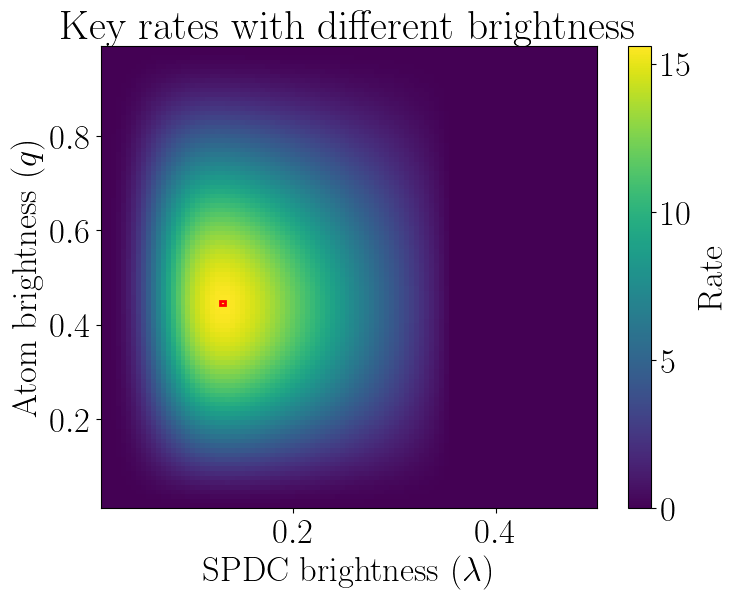

In [8]:
# ... (Assume sk_rates, lam_val_lst, q_val_lst are defined) ...

# 1. Find indices as before
max_idx = np.unravel_index(np.argmax(sk_rates, axis=None), sk_rates.shape)
row, col = max_idx # row is y-index, col is x-index

fig, ax = plt.subplots(figsize=(8, 6))

# 2. Define extent variables explicitly for easier calculation
x_min, x_max = lam_val_lst.min(), lam_val_lst.max()
y_min, y_max = q_val_lst.min(), q_val_lst.max()
extent = [x_min, x_max, y_min, y_max]

im = ax.imshow(sk_rates, 
               origin='lower', 
               extent=extent,
               aspect='auto',
               cmap='viridis')

# 3. Calculate step sizes (pixel width/height in data units)
# shape[1] is columns (x), shape[0] is rows (y)
dx = (x_max - x_min) / sk_rates.shape[1]
dy = (y_max - y_min) / sk_rates.shape[0]

# 4. Calculate the physical bottom-left coordinate of the max pixel
# Since origin='lower', index 0 starts at y_min
rect_x = x_min + (col * dx)
rect_y = y_min + (row * dy)

# 5. Draw the rectangle using physical coordinates and sizes
rect = patches.Rectangle((rect_x, rect_y), dx, dy, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
plt.colorbar(im, label='Rate')
plt.xlabel(r"SPDC brightness ($\lambda$)")
plt.ylabel(r"Atom brightness ($q$)")
plt.title("Key rates with different brightness")
plt.savefig('rate_brightness_50.pdf', bbox_inches='tight')
plt.show()

In [9]:
max_idx

(np.int64(44), np.int64(24))

In [11]:
q_val_lst[44], lam_val_lst[24]

(np.float64(0.44555555555555554), np.float64(0.12878787878787878))